<a href="https://colab.research.google.com/github/Sirigalla34/deep-learning-programs/blob/main/Regularized_Deep_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.2956 - val_loss: 0.1986
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1838 - val_loss: 0.1715
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.1687 - val_loss: 0.1639
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 0.1625 - val_loss: 0.1588
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1594 - val_loss: 0.1585
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1574 - val_loss: 0.1552
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 0.1562 - val_loss: 0.1542
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.1553 - val_loss: 0.1539
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1548 - val_loss: 0.1533
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1542 - val_loss: 0.1523
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1539 - val

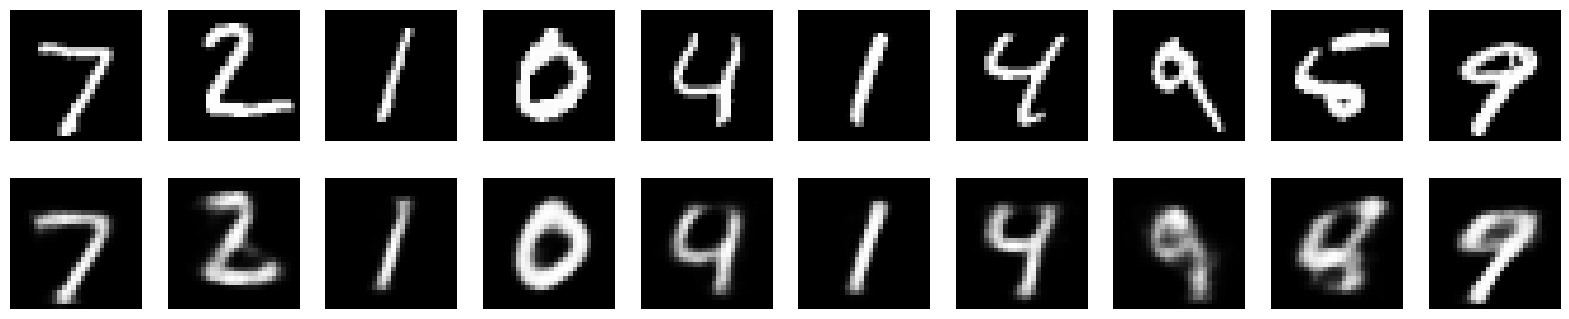

In [1]:
# Regularized Deep Autoencoder
import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

input_dim = 784
encoding_dim1 = 512
encoding_dim2 = 256
encoding_dim3 = 128
reg_factor = 1e-4

input_img = keras.Input(shape=(input_dim,))

encoded = layers.Dense(encoding_dim1, activation="relu", kernel_regularizer=regularizers.l2(reg_factor))(input_img)
encoded = layers.Dense(encoding_dim2, activation="relu", kernel_regularizer=regularizers.l2(reg_factor))(encoded)
encoded = layers.Dense(encoding_dim3, activation="relu", kernel_regularizer=regularizers.l2(reg_factor))(encoded)

decoded = layers.Dense(encoding_dim2, activation="relu", kernel_regularizer=regularizers.l2(reg_factor))(encoded)
decoded = layers.Dense(encoding_dim1, activation="relu", kernel_regularizer=regularizers.l2(reg_factor))(decoded)
decoded = layers.Dense(input_dim, activation="sigmoid", kernel_regularizer=regularizers.l2(reg_factor))(decoded)

autoencoder = keras.Model(inputs=input_img, outputs=decoded)

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20,4))

for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    ax = plt.subplot(2, n, i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()